--- 1. DATA SHAPE (Rows, Columns) ---
Dataset Size: (500, 9)

--- 2. DATA TYPES & NULL VALUES CHECK ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    500 non-null    int64         
 1   Date              500 non-null    datetime64[ns]
 2   Customer_ID       500 non-null    int64         
 3   Gender            500 non-null    object        
 4   Age               500 non-null    int64         
 5   Product_Category  500 non-null    object        
 6   Quantity          500 non-null    int64         
 7   Price_Per_Unit    500 non-null    int64         
 8   Total_Amount      500 non-null    int64         
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 35.3+ KB
None

Missing values in each column:
Transaction_ID      0
Date                0
Customer_ID         0
Gender              0
Age

/tmp/ipykernel_1372/2826697109.py:51: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('Date')['Total_Amount'].resample('M').sum().plot(kind='line', marker='o', color='darkblue', linewidth=2)


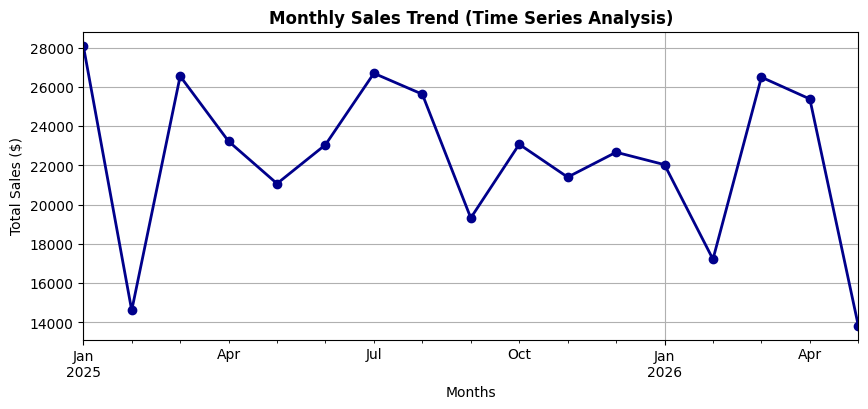

/tmp/ipykernel_1372/2826697109.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='Set2')


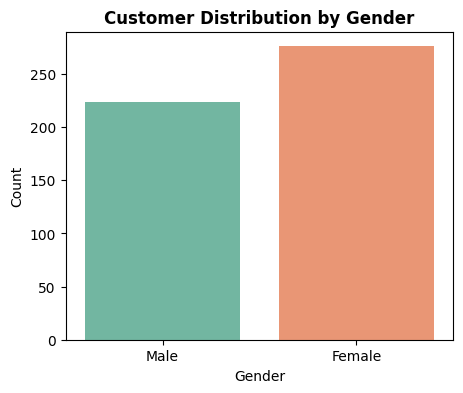

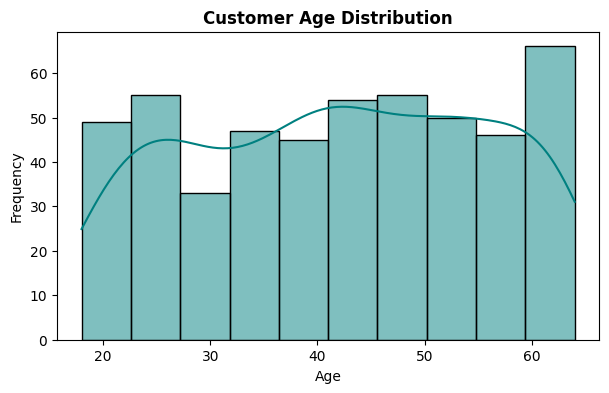

In [1]:
# -------------------------------------------------------------
# STEP 1: Python Libraries Load Karte Hain
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# STEP 2: Task 1 Ke Liye Sample Retail Sales Data Create Karte Hain
# -------------------------------------------------------------
np.random.seed(42)
n_rows = 500

data = {
    'Transaction_ID': range(1001, 1001 + n_rows),
    'Date': pd.date_range(start='2025-01-01', periods=n_rows, freq='D'),
    'Customer_ID': np.random.randint(5000, 5500, size=n_rows),
    'Gender': np.random.choice(['Male', 'Female'], size=n_rows, p=[0.45, 0.55]),
    'Age': np.random.randint(18, 65, size=n_rows),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Beauty', 'Home'], size=n_rows),
    'Quantity': np.random.randint(1, 6, size=n_rows),
    'Price_Per_Unit': np.random.randint(10, 500, size=n_rows)
}

df = pd.DataFrame(data)
df['Total_Amount'] = df['Quantity'] * df['Price_Per_Unit']

# -------------------------------------------------------------
# STEP 3: Initial Data Inspection (Check Column Types & Null Values)
# -------------------------------------------------------------
print("--- 1. DATA SHAPE (Rows, Columns) ---")
print(f"Dataset Size: {df.shape}\n")

print("--- 2. DATA TYPES & NULL VALUES CHECK ---")
print(df.info())
print("\nMissing values in each column:")
print(df.isnull().sum())

# -------------------------------------------------------------
# STEP 4: Descriptive Statistics (Mean, Median, Mode, Std)
# -------------------------------------------------------------
print("\n--- 3. DESCRIPTIVE STATISTICS ---")
print(df[['Age', 'Quantity', 'Price_Per_Unit', 'Total_Amount']].describe())

# -------------------------------------------------------------
# STEP 5: Visualizations (Graphs & Charts)
# -------------------------------------------------------------
# Chart 1: Time Series Analysis (Monthly Sales Trend)
plt.figure(figsize=(10, 4))
df.set_index('Date')['Total_Amount'].resample('M').sum().plot(kind='line', marker='o', color='darkblue', linewidth=2)
plt.title('Monthly Sales Trend (Time Series Analysis)', fontsize=12, fontweight='bold')
plt.xlabel('Months')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.show()

# Chart 2: Customer Gender Breakdown
plt.figure(figsize=(5, 4))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Customer Distribution by Gender', fontsize=12, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# Chart 3: Age Distribution of Customers
plt.figure(figsize=(7, 4))
sns.histplot(df['Age'], bins=10, kde=True, color='teal')
plt.title('Customer Age Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

--- 1. FIRST 5 ROWS WITH CLUSTER LABELS ---
   Customer_ID  Annual_Income_k$  Spending_Score_1to100  Cluster
0          101               117                     23        1
1          102                66                     31        1
2          103               107                     94        0
3          104                29                     42        3
4          105                86                     99        0

--- 2. CUSTOMERS COUNT IN EACH SEGMENT ---
Cluster
0    73
1    91
2    64
3    72
Name: count, dtype: int64


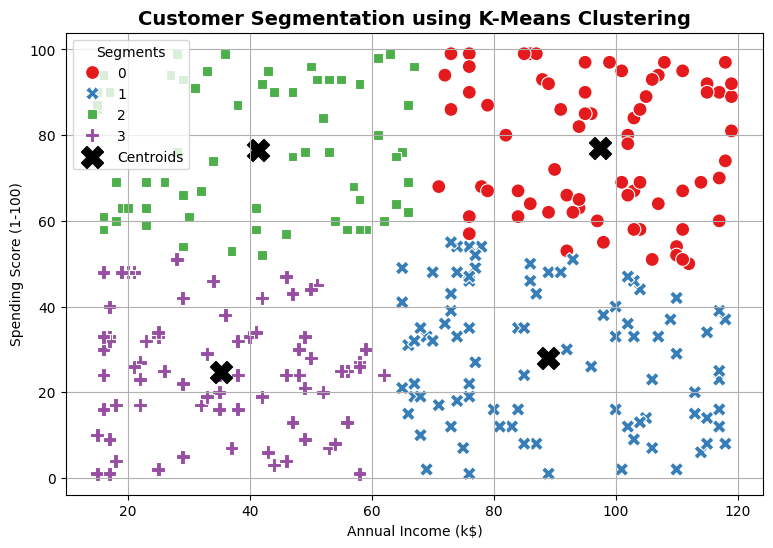

In [2]:
# -------------------------------------------------------------
# STEP 1: Libraries Load Karte Hain (Scikit-Learn Ke Sath)
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# -------------------------------------------------------------
# STEP 2: Dummy E-commerce Customer Data Create Karte Hain
# -------------------------------------------------------------
np.random.seed(42)
n_customers = 300

# Customers ka purchasing behavior generate karna
data = {
    'Customer_ID': range(101, 101 + n_customers),
    'Annual_Income_k$': np.random.randint(15, 120, size=n_customers),
    'Spending_Score_1to100': np.random.randint(1, 100, size=n_customers)
}

df_cust = pd.DataFrame(data)

# -------------------------------------------------------------
# STEP 3: K-Means Clustering Algorithm Apply Karte Hain
# -------------------------------------------------------------
# Clustering ke liye features select karna (Income aur Spending Score)
X = df_cust[['Annual_Income_k$', 'Spending_Score_1to100']]

# Hum 4 groups (clusters) me customers ko segment karenge
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_cust['Cluster'] = kmeans.fit_predict(X)

# -------------------------------------------------------------
# STEP 4: Results Print & Inspect Karna
# -------------------------------------------------------------
print("--- 1. FIRST 5 ROWS WITH CLUSTER LABELS ---")
print(df_cust.head())

print("\n--- 2. CUSTOMERS COUNT IN EACH SEGMENT ---")
print(df_cust['Cluster'].value_counts().sort_index())

# -------------------------------------------------------------
# STEP 5: Visualizing the Customer Segments (Graph)
# -------------------------------------------------------------
plt.figure(figsize=(9, 6))
# Alag-alag clusters ko different colors se plot karna
sns.scatterplot(
    x='Annual_Income_k$',
    y='Spending_Score_1to100',
    hue='Cluster',
    data=df_cust,
    palette='Set1',
    s=100,
    style='Cluster'
)

# Clusters ke centers (centroids) ko plot karna
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation using K-Means Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Segments')
plt.grid(True)
plt.show()

--- 1. CLEANED DATA SUCCESSFUL ---
   Employee_ID   Name   Age   Salary  Join_Date
0            1   Amit  25.0  50000.0 2023-01-15
1            2  Rahul  31.0  60000.0 2023-02-20
2            3   Sita  30.0  59000.0 2023-03-10
3            4  Vijay  22.0  45000.0 2023-01-15
4            5  Rahul  31.0  60000.0 2023-02-20
5            6  Pooja  28.0  70000.0 2023-05-12
6            7    Raj  45.0  59000.0 2023-06-01
7            8   Neha  31.0  52000.0 2023-04-18
8            9  Sunil  35.0  58000.0 2023-07-22
9           10   Alok  29.0  65000.0 2023-08-19


/tmp/ipykernel_1372/296694209.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Before Cleaning', 'After Cleaning'], y=[missing_before, missing_after], palette='cool')


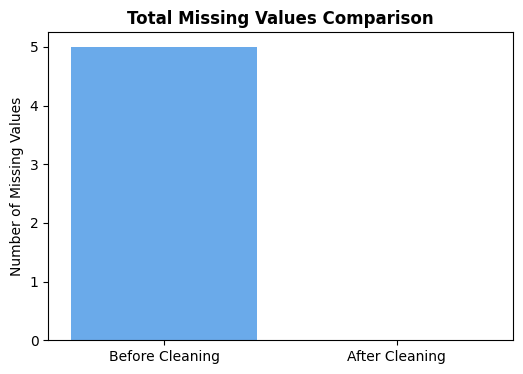

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Simple List structure to avoid any comma or bracket syntax error
emp_ids = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
names = ['Amit', 'Rahul', 'Sita', 'Vijay', 'Rahul', 'Pooja', 'Raj', 'Neha', 'Sunil', 'Alok']
ages = [25, np.nan, 30, 22, np.nan, 28, 45, np.nan, 35, 29]
salaries = [50000, 60000, np.nan, 45000, 60000, 70000, np.nan, 52000, 58000, 65000]
dates = ['2023-01-15', '2023-02-20', '2023-03-10', '2023-01-15', '2023-02-20', '2023-05-12', '2023-06-01', '2023-04-18', '2023-07-22', '2023-08-19']

# Creating DataFrame
df_dirty = pd.DataFrame({
    'Employee_ID': emp_ids,
    'Name': names,
    'Age': ages,
    'Salary': salaries,
    'Join_Date': dates
})

# Data Cleaning Process
df_clean = df_dirty.drop_duplicates().copy()
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].mean().round())
df_clean['Salary'] = df_clean['Salary'].fillna(df_clean['Salary'].median())
df_clean['Join_Date'] = pd.to_datetime(df_clean['Join_Date'])

print("--- 1. CLEANED DATA SUCCESSFUL ---")
print(df_clean)

# Bar Graph Plotting
plt.figure(figsize=(6, 4))
missing_before = df_dirty.isnull().sum().sum()
missing_after = df_clean.isnull().sum().sum()

sns.barplot(x=['Before Cleaning', 'After Cleaning'], y=[missing_before, missing_after], palette='cool')
plt.title('Total Missing Values Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Number of Missing Values')
plt.show()